# 01 Data Prep

Notebook for bronze ingestion, EDA, and silver cleaning with lakeFS.

## Section 1.1 - Setup & Configuration

In [1]:
import logging

import lakefs
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from helpers import (
    add_delay_precursor,
    create_branch,
    create_is_delayed_target,
    drop_cancelled_flights,
    handle_remaining_missing_values,
    drop_missing_arrival_delay,
    filter_to_year,
    lakefs_commit,
    normalize_silver_dtypes,
    read_parquet,
    remove_negative_air_time,
    save_chart,
    stratified_sample_with_row_cap,
    write_parquet,
)
from notebook_setup import build_notebook_config, initialize_lakefs_repository

logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s")

In [2]:
config = build_notebook_config()
print("lakeFS endpoint:", config.endpoint)
print("lakeFS repo:", config.repo_name)
print("raw csv path:", config.raw_csv_path)
print("sample_size_cap:", config.sample_size_cap)
print("random_seed:", config.random_seed)

lakeFS endpoint: http://lakefs.scilake.svc:8080
lakeFS repo: flight-delay-demo
raw csv path: data/raw/flights_sample_3m.csv
sample_size_cap: 500000
random_seed: 42


In [3]:
init_result = initialize_lakefs_repository(config)
print(init_result.message)

lakefs_client = lakefs.Client(
    host=config.endpoint,
    username=config.access_key,
    password=config.secret_key,
)

Connected to lakeFS repository 'flight-delay-demo' at http://lakefs.scilake.svc:8080. default_branch_exists=True.


## Section 1.2 - Bronze Layer (main branch)

In [4]:
raw_df = pd.read_csv(config.raw_csv_path)
raw_df["year"] = pd.to_datetime(raw_df["FL_DATE"], errors="coerce").dt.year

flights_2023 = filter_to_year(raw_df, year=2023, year_column="year")
flights_2023 = flights_2023.rename(columns={"ARR_DELAY": "arrival_delay"})
flights_2023 = add_delay_precursor(flights_2023, arrival_delay_col="arrival_delay")

if len(flights_2023) > config.sample_size_cap:
    flights_2023 = stratified_sample_with_row_cap(
        flights_2023,
        target_col="is_delayed_pre",
        row_cap=config.sample_size_cap,
        random_seed=config.random_seed,
    )

print("bronze rows:", len(flights_2023))
print("bronze columns:", flights_2023.shape[1])

bronze rows: 463484
bronze columns: 34


In [5]:
write_parquet(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=config.default_branch,
    path="bronze/flights_2023.parquet",
    df=flights_2023,
)

bronze_commit_ref = lakefs_commit(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name=config.default_branch,
    message="Ingest raw 2023 flight data (bronze layer)",
    metadata={"phase": "phase-2", "layer": "bronze"},
)
if bronze_commit_ref is None:
    print("No new bronze changes to commit; continuing with existing state.")
else:
    print("bronze commit:", getattr(bronze_commit_ref, "id", bronze_commit_ref))

No new bronze changes to commit; continuing with existing state.


## Section 1.3 - EDA (Exploratory Data Analysis)

In [6]:
rows, cols = flights_2023.shape
class_balance = flights_2023["is_delayed_pre"].value_counts(normalize=True).sort_index()
missing_summary = flights_2023.isna().sum().sort_values(ascending=False)

print(f"rows: {rows:,}  cols: {cols}")
print("class balance (is_delayed_pre):")
print((class_balance * 100).round(2).astype(str) + "%")
print("\nmissing values (top 15):")
print(missing_summary.head(15))

rows: 463,484  cols: 34
class balance (is_delayed_pre):
is_delayed_pre
0    78.15%
1    21.85%
Name: proportion, dtype: str

missing values (top 15):
CANCELLATION_CODE          455675
DELAY_DUE_LATE_AIRCRAFT    358825
DELAY_DUE_NAS              358825
DELAY_DUE_SECURITY         358825
DELAY_DUE_CARRIER          358825
DELAY_DUE_WEATHER          358825
AIR_TIME                     9071
ELAPSED_TIME                 9071
arrival_delay                9071
WHEELS_ON                    7928
ARR_TIME                     7928
TAXI_IN                      7928
WHEELS_OFF                   7764
TAXI_OUT                     7764
DEP_DELAY                    7540
dtype: int64


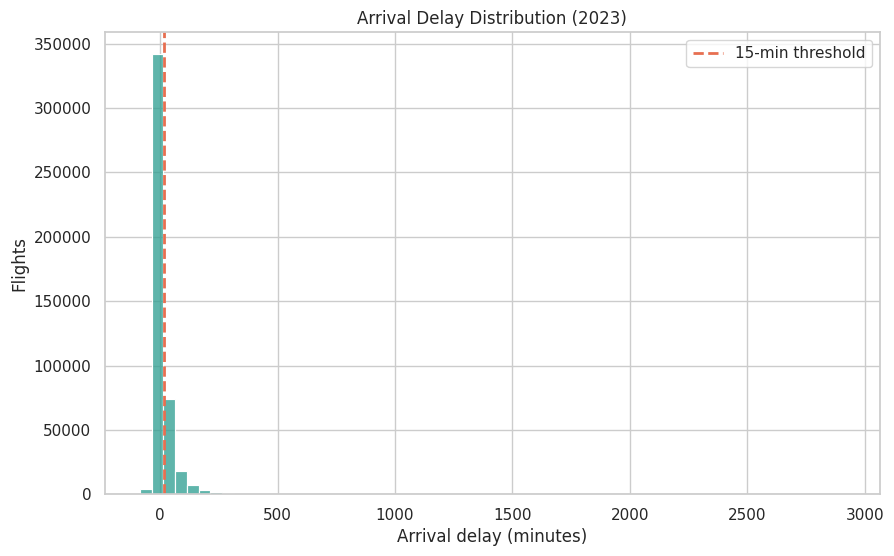

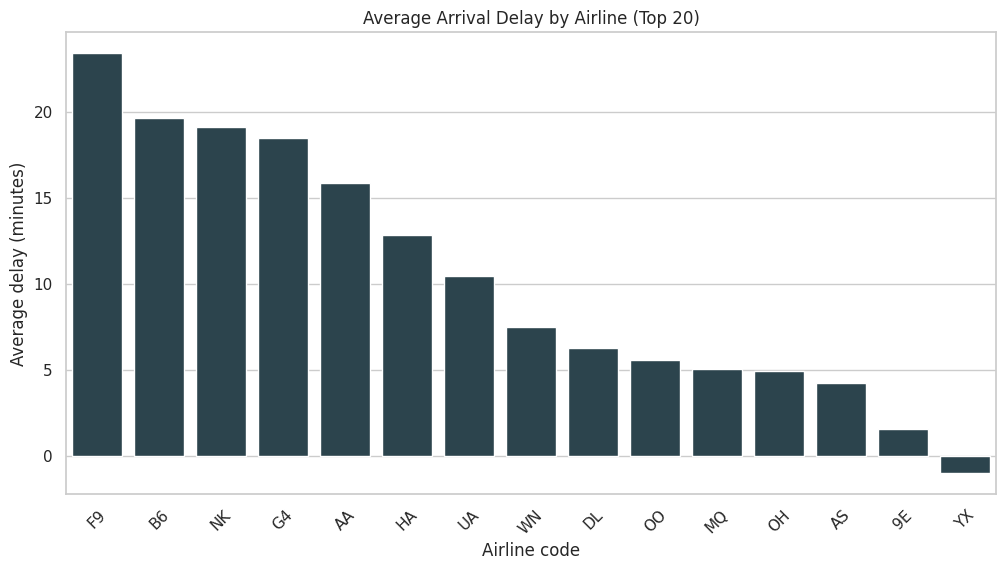

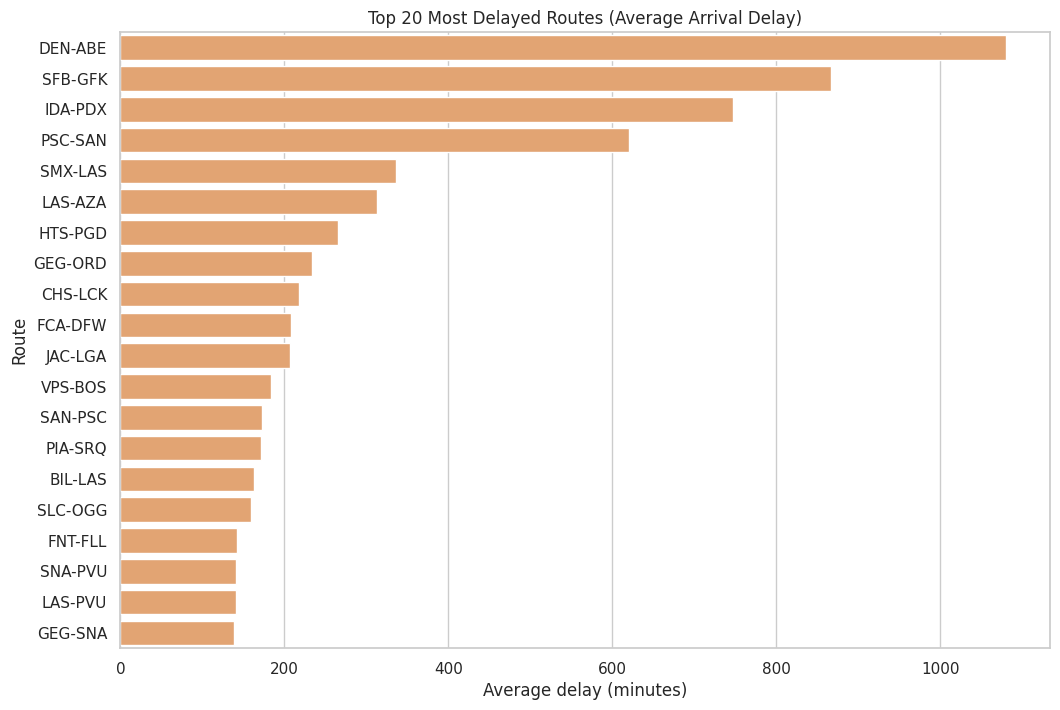

In [7]:
sns.set_theme(style="whitegrid")

fig1, ax1 = plt.subplots(figsize=(10, 6))
sns.histplot(flights_2023["arrival_delay"].dropna(), bins=60, ax=ax1, color="#2a9d8f")
ax1.axvline(15, color="#e76f51", linestyle="--", linewidth=2, label="15-min threshold")
ax1.set_title("Arrival Delay Distribution (2023)")
ax1.set_xlabel("Arrival delay (minutes)")
ax1.set_ylabel("Flights")
ax1.legend()
save_chart(fig1, "delay_histogram.png")

airline_delay = (
    flights_2023.groupby("AIRLINE_CODE", dropna=False)["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
fig2, ax2 = plt.subplots(figsize=(12, 6))
sns.barplot(x=airline_delay.index, y=airline_delay.values, ax=ax2, color="#264653")
ax2.set_title("Average Arrival Delay by Airline (Top 20)")
ax2.set_xlabel("Airline code")
ax2.set_ylabel("Average delay (minutes)")
ax2.tick_params(axis="x", rotation=45)
save_chart(fig2, "delay_by_airline.png")

route_delay = (
    flights_2023.assign(route=flights_2023["ORIGIN"].astype(str) + "-" + flights_2023["DEST"].astype(str))
    .groupby("route", dropna=False)["arrival_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)
fig3, ax3 = plt.subplots(figsize=(12, 8))
sns.barplot(x=route_delay.values, y=route_delay.index, ax=ax3, color="#f4a261")
ax3.set_title("Top 20 Most Delayed Routes (Average Arrival Delay)")
ax3.set_xlabel("Average delay (minutes)")
ax3.set_ylabel("Route")
save_chart(fig3, "top_delayed_routes.png")

plt.show()

## Section 1.4 - Silver Layer (silver branch)

TODO: Clean bronze data, create `is_delayed`, and write `silver/flights_2023_clean.parquet`.

In [ ]:
create_branch(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name="silver",
    source_branch=config.default_branch,
)

In [ ]:
silver_df = read_parquet(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name="silver",
    path="bronze/flights_2023.parquet",
)

rows_initial = len(silver_df)
silver_df = drop_cancelled_flights(silver_df, cancelled_col="CANCELLED")
rows_after_cancelled = len(silver_df)
silver_df = drop_missing_arrival_delay(silver_df, arrival_delay_col="arrival_delay")
rows_after_missing_delay = len(silver_df)
silver_df, missing_value_audit = handle_remaining_missing_values(silver_df)
rows_after_missing_policy = len(silver_df)
silver_df = remove_negative_air_time(silver_df, air_time_col="AIR_TIME")
rows_after_negative_air_time = len(silver_df)
silver_df, dtype_audit = normalize_silver_dtypes(silver_df)
rows_after_dtype_normalization = len(silver_df)
silver_df = create_is_delayed_target(silver_df, arrival_delay_col="arrival_delay", output_col="is_delayed")

print("rows initial:", rows_initial)
print("removed cancelled:", rows_initial - rows_after_cancelled)
print("removed missing arrival_delay:", rows_after_cancelled - rows_after_missing_delay)
print("removed by remaining-missing policy:", rows_after_missing_delay - rows_after_missing_policy)
print("missing-value audit:", missing_value_audit)
print("removed negative AIR_TIME:", rows_after_missing_policy - rows_after_negative_air_time)
print("dtype normalization rows changed:", rows_after_negative_air_time - rows_after_dtype_normalization)
print("dtype audit:", dtype_audit)
print("final shape:", silver_df.shape)

In [ ]:
write_parquet(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name="silver",
    path="silver/flights_2023_clean.parquet",
    df=silver_df,
)

silver_commit_ref = lakefs_commit(
    client=lakefs_client,
    repo_name=config.repo_name,
    branch_name="silver",
    message="Clean flight data, create delay target (silver layer)",
    metadata={"phase": "phase-3", "layer": "silver"},
)
if silver_commit_ref is None:
    print("No new silver changes to commit; continuing with existing state.")
else:
    print("silver commit:", getattr(silver_commit_ref, "id", silver_commit_ref))